# Tournament — Build and Battle Your Trading Agent
**PoliMi GSOM Algorithmic Trading 2026**

This notebook runs the class tournament: all team agents compete in a single
shared RMSC04 market (same seed, MomentumAgents replaced by student agents),
then displays the PnL league table and per-agent diagnostics.

---
**Before running:** make sure `AGENT_REGISTRY` in `tools/run_tournament.py`
contains one entry for every team.

## 0 · Setup

In [1]:
import os, sys

# Ensure the repo root is on the path so student_work.* imports resolve
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## 1 · Run the tournament

This calls the same `run()` function used by the command-line script, so
results are identical whether you run it here or from the terminal.

Change `SEED` or `END_TIME` to explore different market scenarios.

In [19]:
SEED     = 21
END_TIME = "17:30:00"   # full trading day; use "10:00:00" for a quick run
OUT_DIR  = os.path.join(REPO_ROOT, "log", "tournament")

from tools.run_tournament import run

results = run(seed=SEED, end_time=END_TIME, out_dir=OUT_DIR)
results

[tournament] Building config  seed=21  end_time=17:30:00
[tournament] 3 team agent(s) registered: Group A – Mean Reversion, Group B – Trend Follower, Group C – Liquidity Provider
[tournament] Total agents in simulation: 1108
[tournament] Running simulation…
[tournament] Collecting results…

  TOURNAMENT LEAGUE TABLE
  Rank  Team                                      PnL
--------------------------------------------------------------
  1     Group B – Trend Follower          ▲ $     97.20
  2     Group C – Liquidity Provider      ▼ $   -221.72
  3     Group A – Mean Reversion          ▼ $   -798.20

[tournament] Results saved      → /abides/log/tournament/tournament_results.csv
[tournament] League table saved → /abides/log/tournament/league_table.png


,rank,team,strategy,final_mtm,pnl_cents,pnl_dollars,shares_held
0,1,Group B – Trend Follower,TrendFollowerAgent,10009720,9720,97.20,40
1,2,Group C – Liquidity Provider,LiquidityProviderAgent,9977828,-22172,-221.72,-6
2,3,Group A – Mean Reversion,MeanReversionAgent,9920180,-79820,-798.20,-200


## 2 · League table

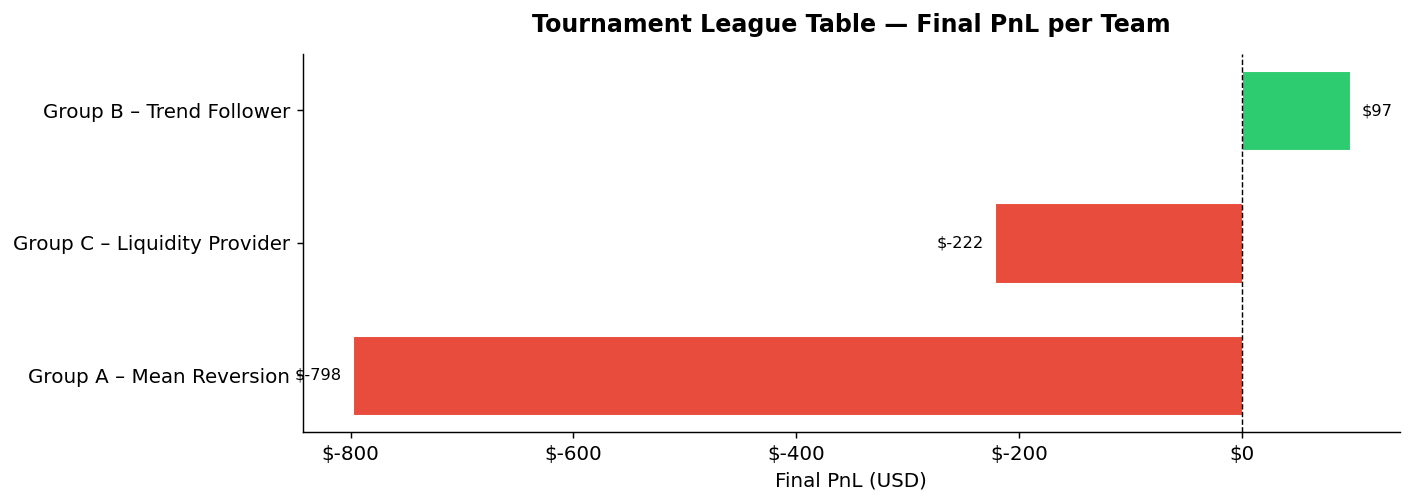

In [20]:
df = results.copy().iloc[::-1].reset_index(drop=True)   # best at top when plotted

colours = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df["pnl_dollars"]]

fig, ax = plt.subplots(figsize=(11, max(4, len(df) * 0.6 + 1.5)))

bars = ax.barh(df["team"], df["pnl_dollars"], color=colours,
               edgecolor="white", linewidth=0.6, height=0.6)

for bar, val in zip(bars, df["pnl_dollars"]):
    label  = f"${val:,.0f}"
    x_off  = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01 or 1
    ha     = "left" if val >= 0 else "right"
    ax.text(bar.get_width() + (x_off if val >= 0 else -x_off),
            bar.get_y() + bar.get_height() / 2,
            label, va="center", ha=ha, fontsize=9)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Final PnL (USD)")
ax.set_title("Tournament League Table — Final PnL per Team",
             fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig

## 3 · PnL summary statistics

In [14]:
summary = results[["team", "strategy", "pnl_dollars", "shares_held"]].copy()
summary["pnl_dollars"] = summary["pnl_dollars"].map("${:,.2f}".format)
summary.index = summary.pop("team")
summary

,strategy,pnl_dollars,shares_held
team,,,
Group A – Mean Reversion,MeanReversionAgent,$48.35,0
Group B – Trend Follower,TrendFollowerAgent,$28.00,0
Group C – Liquidity Provider,LiquidityProviderAgent,$-182.23,3


## 4 · End-of-day inventory

Agents that hold a non-zero position at close are exposed to overnight
risk.  A large residual inventory often signals that the strategy did not
fully unwind — either by design (trend follower holding through the close)
or by accident (mean-reversion agent stuck on the wrong side).

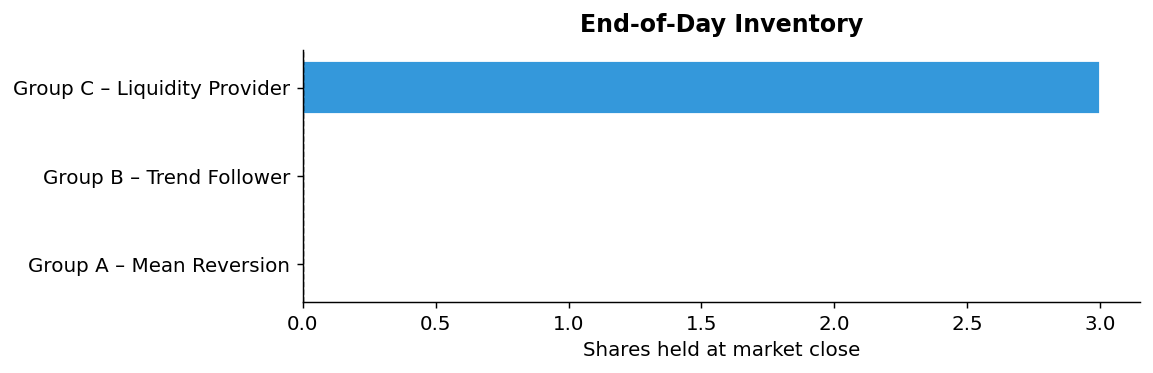

In [15]:
fig, ax = plt.subplots(figsize=(9, max(3, len(results) * 0.55 + 1)))

inv = results.set_index("team")["shares_held"].sort_values()
colours_inv = ["#3498db" if v >= 0 else "#e67e22" for v in inv]
ax.barh(inv.index, inv.values, color=colours_inv, edgecolor="white", height=0.6)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Shares held at market close")
ax.set_title("End-of-Day Inventory", fontweight="bold", pad=10)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig

## 5 · Sensitivity to seed (optional)

Run the tournament over several seeds to see whether the ranking is stable
or highly path-dependent.  This takes a few minutes — skip if short on time.

In [18]:
 #── uncomment to run ──────────────────────────────────────────────────────────
SEEDS = [2, 42, 123, 777, 2024, 31415]
all_runs = []
for s in SEEDS:
    r = run(seed=s, end_time="17:30:00", out_dir=OUT_DIR)
    r["seed"] = s
    all_runs.append(r)

multi = pd.concat(all_runs, ignore_index=True)

pivot = multi.pivot_table(
    index="team", values="pnl_dollars",
    aggfunc=["mean", "std", "min", "max"]
).round(2)
pivot.columns = ["_".join(c) for c in pivot.columns]
pivot.sort_values("mean_pnl_dollars", ascending=False)
#pass

[tournament] Building config  seed=2  end_time=16:00:00
[tournament] 3 team agent(s) registered: Group A – Mean Reversion, Group B – Trend Follower, Group C – Liquidity Provider
[tournament] Total agents in simulation: 1108
[tournament] Running simulation…
[tournament] Collecting results…

  TOURNAMENT LEAGUE TABLE
  Rank  Team                                      PnL
--------------------------------------------------------------
  1     Group B – Trend Follower          ▲ $     48.80
  2     Group A – Mean Reversion          ▼ $    -90.63
  3     Group C – Liquidity Provider      ▼ $   -206.42

[tournament] Results saved      → /abides/log/tournament/tournament_results.csv
[tournament] League table saved → /abides/log/tournament/league_table.png
[tournament] Building config  seed=42  end_time=16:00:00
[tournament] 3 team agent(s) registered: Group A – Mean Reversion, Group B – Trend Follower, Group C – Liquidity Provider
[tournament] Total agents in simulation: 1108
[tournament] Runni

,mean_pnl_dollars,std_pnl_dollars,min_pnl_dollars,max_pnl_dollars
team,,,,
Group B – Trend Follower,35.93,12.69,18.00,48.80
Group C – Liquidity Provider,-228.81,18.89,-250.11,-206.42
Group A – Mean Reversion,-333.13,429.48,-845.00,326.83


---
*Generated by `notebooks/tournament.ipynb` · PoliMi GSOM Algorithmic Trading 2026*